## Import Libraries and Create Training Data

Import required libraries and create the training dataset.
`x_train` contains input features and `y_train` contains target values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math 

x_train = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10,
    11, 12, 13, 14, 15,
    16, 17, 18, 19, 20
], dtype=float)

y_train = np.array([
    105, 202, 310, 398, 505,
    610, 702, 810, 905, 1008,
    1110, 1195, 1302, 1405, 1500,
    1598, 1708, 1795, 1902, 2005
], dtype=float)

## Compute Cost Function

Calculate the Mean Squared Error (MSE) cost for the current values of `w` and `b`.

The cost measures how well the regression line fits the training data.

In [2]:
def cost_fn(x, y, w, b):
    m = len(x)
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b 
        cost += (f_wb - y[i])**2
    return cost / (2 * m)

## Compute Partial Derivative with Respect to w

Calculate the gradient of the cost function with respect to the weight parameter `w`.

This indicates how `w` should be adjusted to reduce the cost.

In [3]:
def compute_djdw(x, y, w, b):
    m = len(x)
    d_jw = 0
    for i in range(m):
        f_wb = w * x[i] + b 
        d_jw += (f_wb - y[i]) * x[i]
    dj_dw = d_jw / m

    return dj_dw

## Compute Partial Derivative with Respect to b

Calculate the gradient of the cost function with respect to the bias parameter `b`.

This indicates how `b` should be adjusted to reduce the cost.

In [4]:
def compute_djdb(x, y, w, b):
    m = len(x)
    d_jb = 0
    for i in range(m):
        f_wb = w * x[i] + b 
        d_jb += (f_wb - y[i]) 
    dj_db = d_jb / m

    return dj_db

## Perform Gradient Descent

Iteratively update `w` and `b` using the computed gradients.

The parameters are adjusted in the direction that minimizes the cost function.

In [5]:
def gradient_descent(x, y, alpha, iteration, w_in, b_in):
    w = w_in
    b = b_in
    j_history = []
    p_history = []
    for i in range(iteration):
        
        temp_w = w - alpha * compute_djdw(x, y, w, b)
        temp_b = b - alpha * compute_djdb(x, y, w, b)
        w = temp_w
        b = temp_b
        if i < 10000:
            j_history.append(cost_fn(x, y, w, b))
            #p_history.append([w,b])
        if i% math.ceil(iteration/10)==0:
            print(f"Cost:{j_history[i]:.8f},w={w},b={b}")
            
    return (w , b, j_history)

## Train the Linear Regression Model

Specify the learning rate, number of iterations, and initial parameter values.

Run gradient descent to obtain the optimal values of `w` and `b`.

In [6]:
iterations = 10000
step_size = 1.0e-2
w_in, b_in = 1000 , 90
w_final, b_final, j_history = gradient_descent(x_train, y_train, step_size, iterations , w_in, b_in)

Cost:11551682.57773395,w=-300.63350000000014,b=-5.362499999999997
Cost:10.60578189,w=99.63858481222533,b=7.950793256432927
Cost:10.24993202,w=99.75482240541238,b=6.36476419150937
Cost:10.24640744,w=99.76639063357398,b=6.2069189919409835
Cost:10.24637253,w=99.7675419298038,b=6.191209880690874
Cost:10.24637218,w=99.7676565094084,b=6.189646474410906
Cost:10.24637218,w=99.76766791262979,b=6.189490880682059
Cost:10.24637218,w=99.76766904750417,b=6.189475395642267
Cost:10.24637218,w=99.76766916044944,b=6.189473854536082
Cost:10.24637218,w=99.76766917169002,b=6.189473701161719


## Visualize the Learned Regression Line

Generate predictions using the learned parameters and plot:

- Training data points as a scatter plot
- The learned regression line

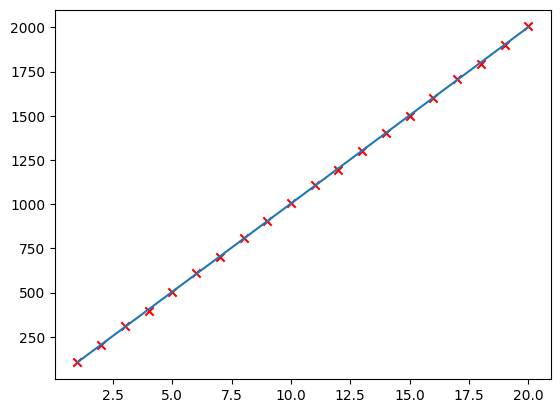

In [7]:
def y_prediction(x, w, b):
    m = len(x)
    f_wb = w*x + b
    return f_wb

plt.scatter(x_train, y_train, marker='x', c='r')
plt.plot(x_train, y_prediction(x_train, w_final, b_final))
plt.show()


## Cost versus iterations of gradient descent

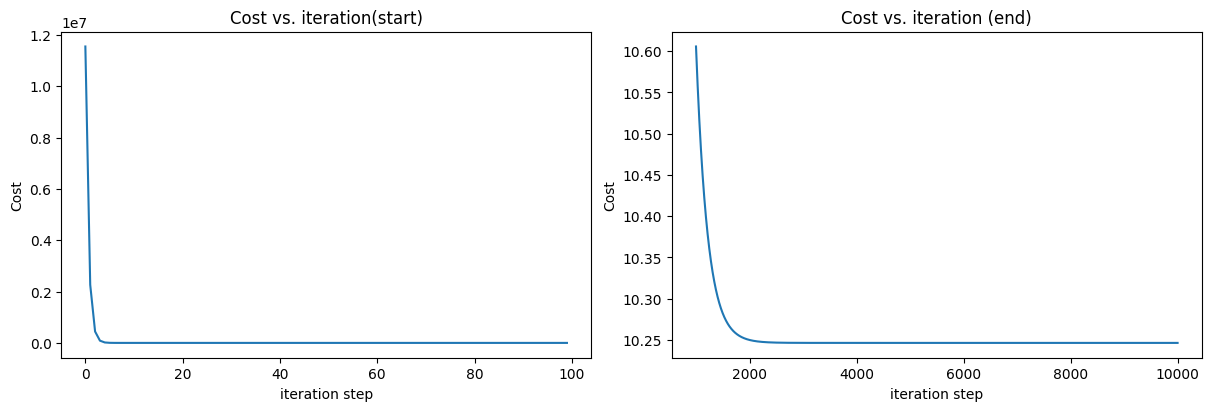

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True, figsize = (12, 4))
ax1.plot(j_history[:100])
ax2.plot(1000+np.arange(len(j_history[1000:])),j_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

Predict the outcome for input value 24

In [9]:
k = np.array([24])
y_prediction(k , w_final, b_final)

array([2400.61353383])